In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [87]:
data = pd.read_csv("city_day.csv")
data.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [88]:
print("Shape:", data.shape)
print("Columns:", data.columns)
print(data.dtypes)

Shape: (29531, 16)
Columns: Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object


In [89]:
data.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [90]:
data['Date'] = pd.to_datetime(data['Date'])

data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day

data = data.drop('Date', axis=1)

In [91]:
for col in data.columns:
    if data[col].dtype != 'object':
        mean_value = data[col].mean()
        data[col] = data[col].fillna(mean_value)

In [92]:
data['PM_ratio'] = data['PM2.5'] / (data['PM10'] + 1)
data['NOx_ratio'] = data['NO'] / (data['NO2'] + 1)

data['is_winter'] = data['Month'].isin([11,12,1,2]).astype(int)
data['is_monsoon'] = data['Month'].isin([6,7,8]).astype(int)

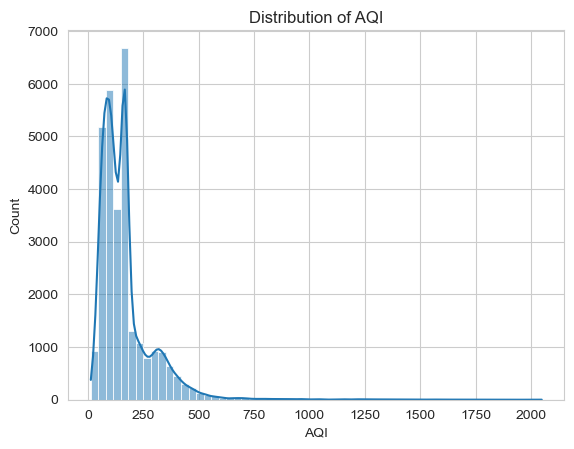

In [93]:
plt.figure()
sns.histplot(data['AQI'], bins=60, kde=True)
plt.title("Distribution of AQI")
plt.show()

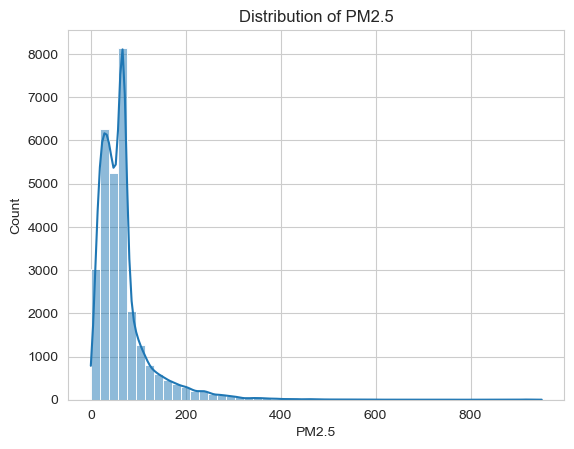

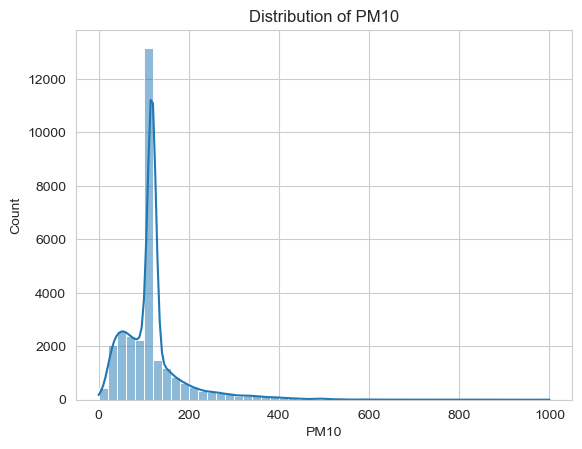

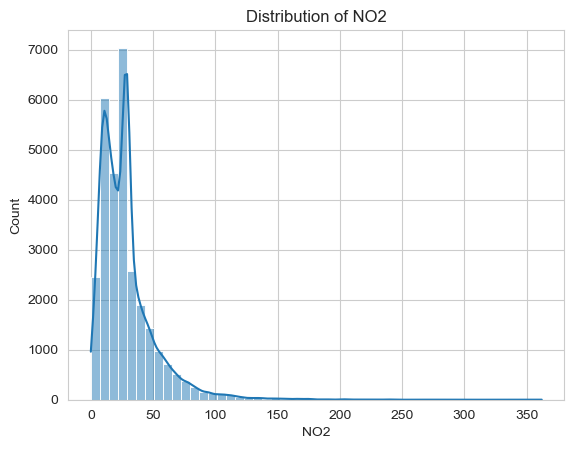

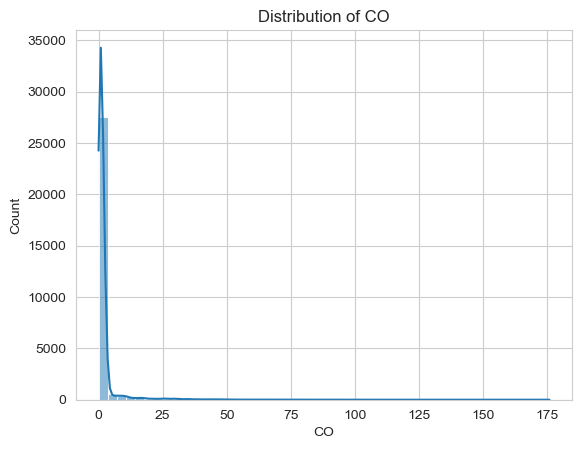

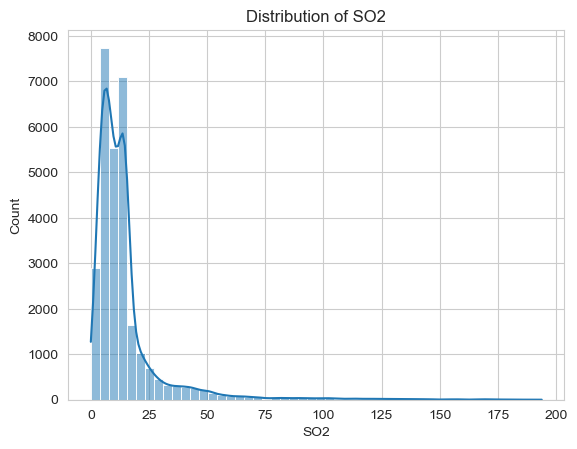

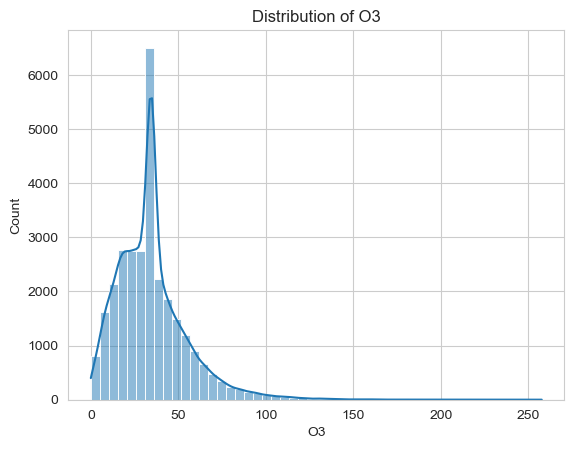

In [94]:
pollutants = ['PM2.5','PM10','NO2','CO','SO2','O3']

for col in pollutants:
    plt.figure()
    sns.histplot(data[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

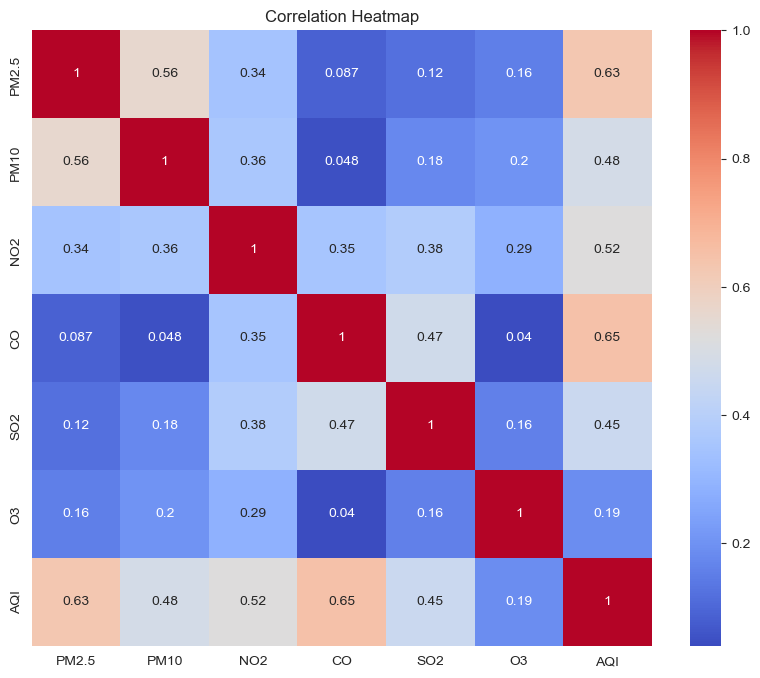

In [95]:
plt.figure(figsize=(10,8))
sns.heatmap(data[pollutants + ['AQI']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

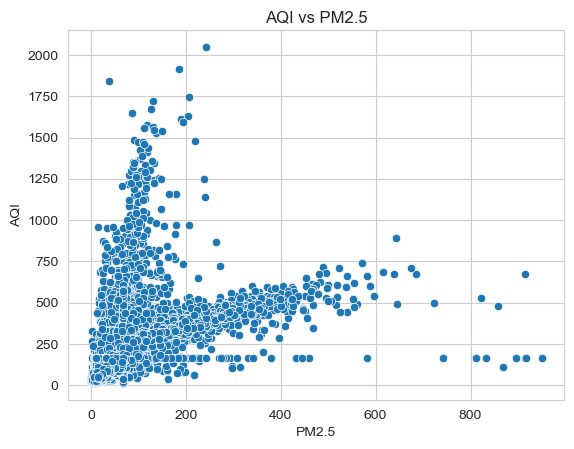

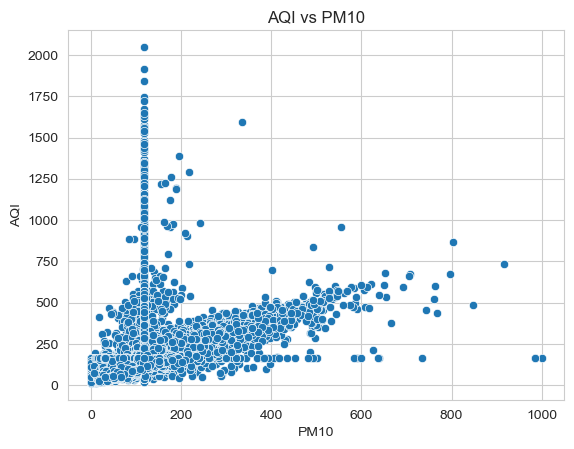

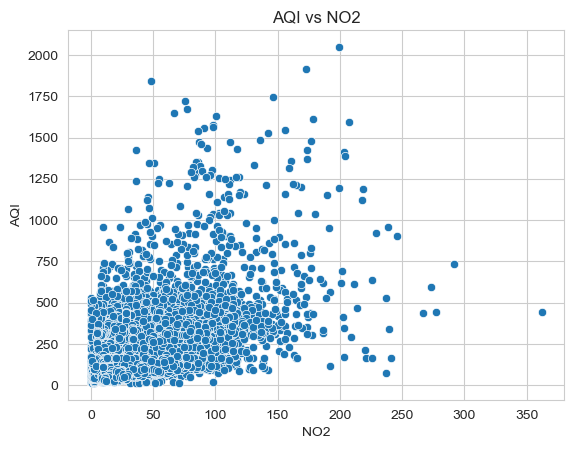

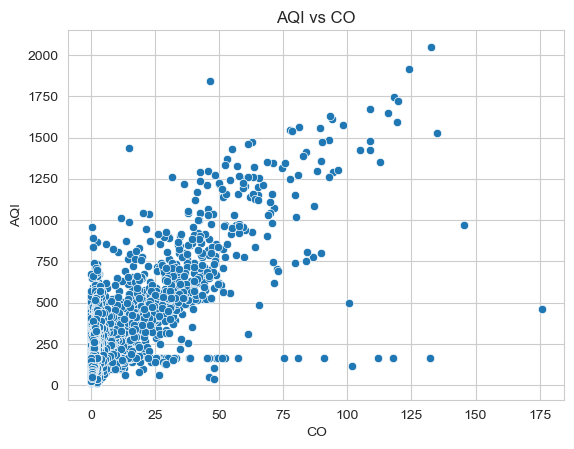

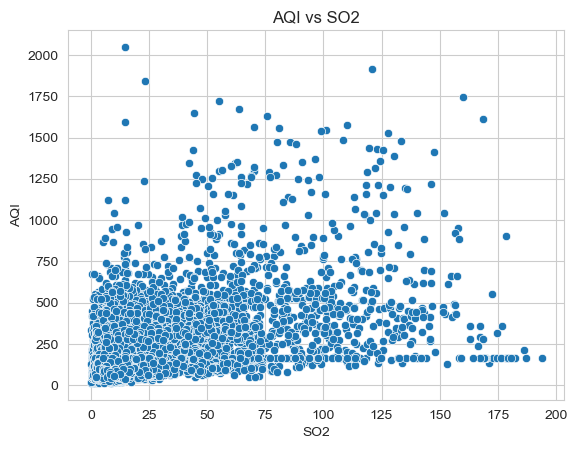

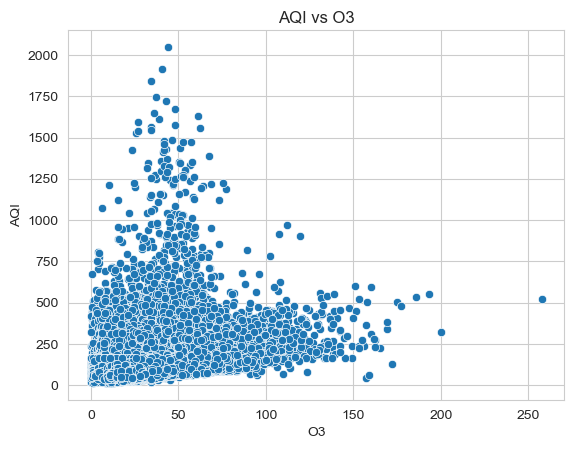

In [96]:
for col in pollutants:
    plt.figure()
    sns.scatterplot(x=data[col], y=data['AQI'])
    plt.title(f"AQI vs {col}")
    plt.show()

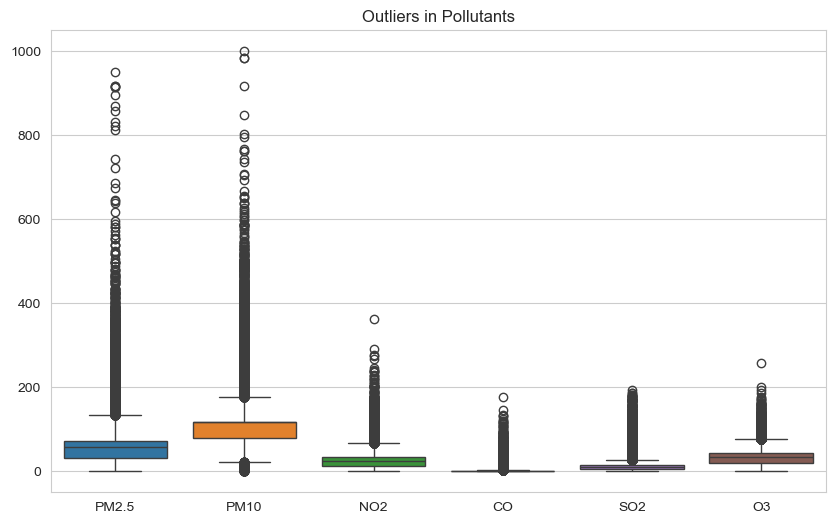

In [97]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data[pollutants])
plt.title("Outliers in Pollutants")
plt.show()

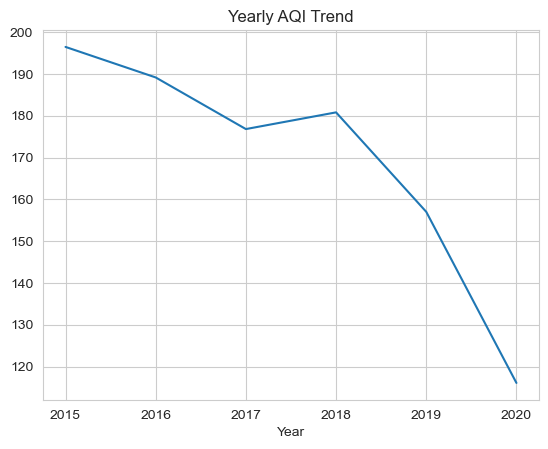

In [98]:
plt.figure()
data.groupby('Year')['AQI'].mean().plot()
plt.title("Yearly AQI Trend")
plt.show()

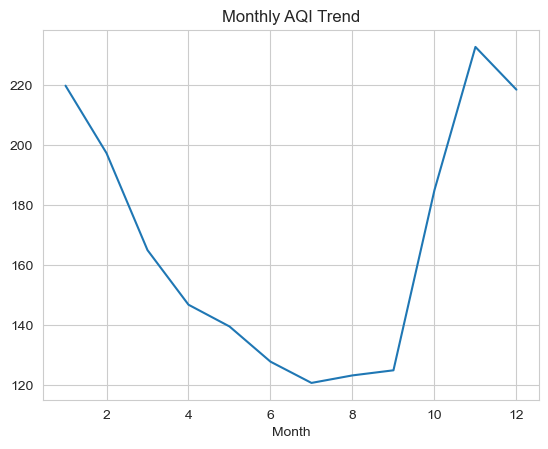

In [99]:
plt.figure()
data.groupby('Month')['AQI'].mean().plot()
plt.title("Monthly AQI Trend")
plt.show()

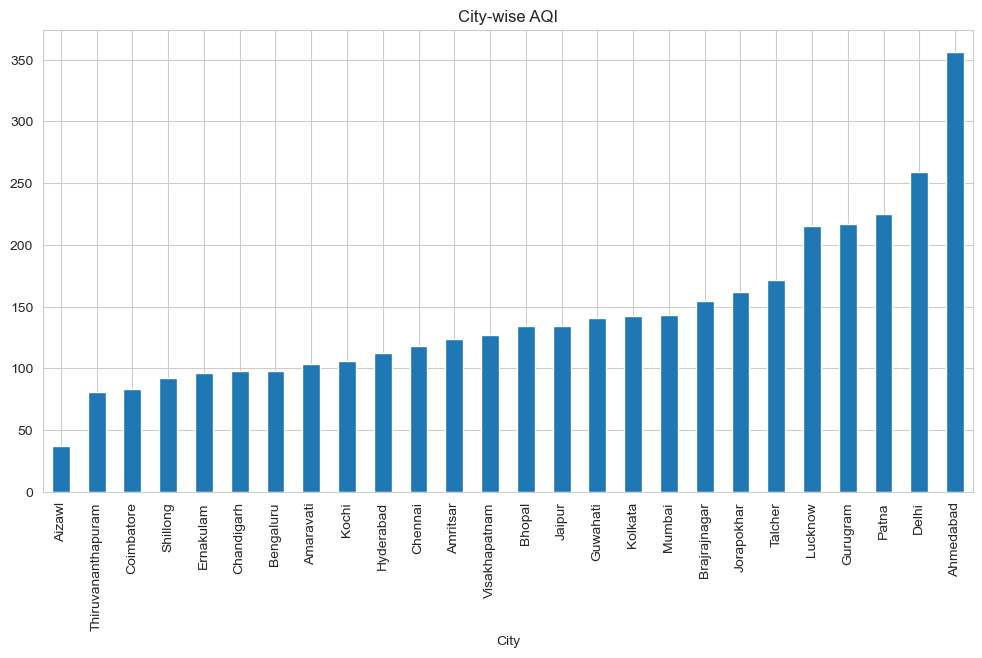

In [100]:
plt.figure(figsize=(12,6))
data.groupby('City')['AQI'].mean().sort_values().plot(kind='bar')
plt.title("City-wise AQI")
plt.show()

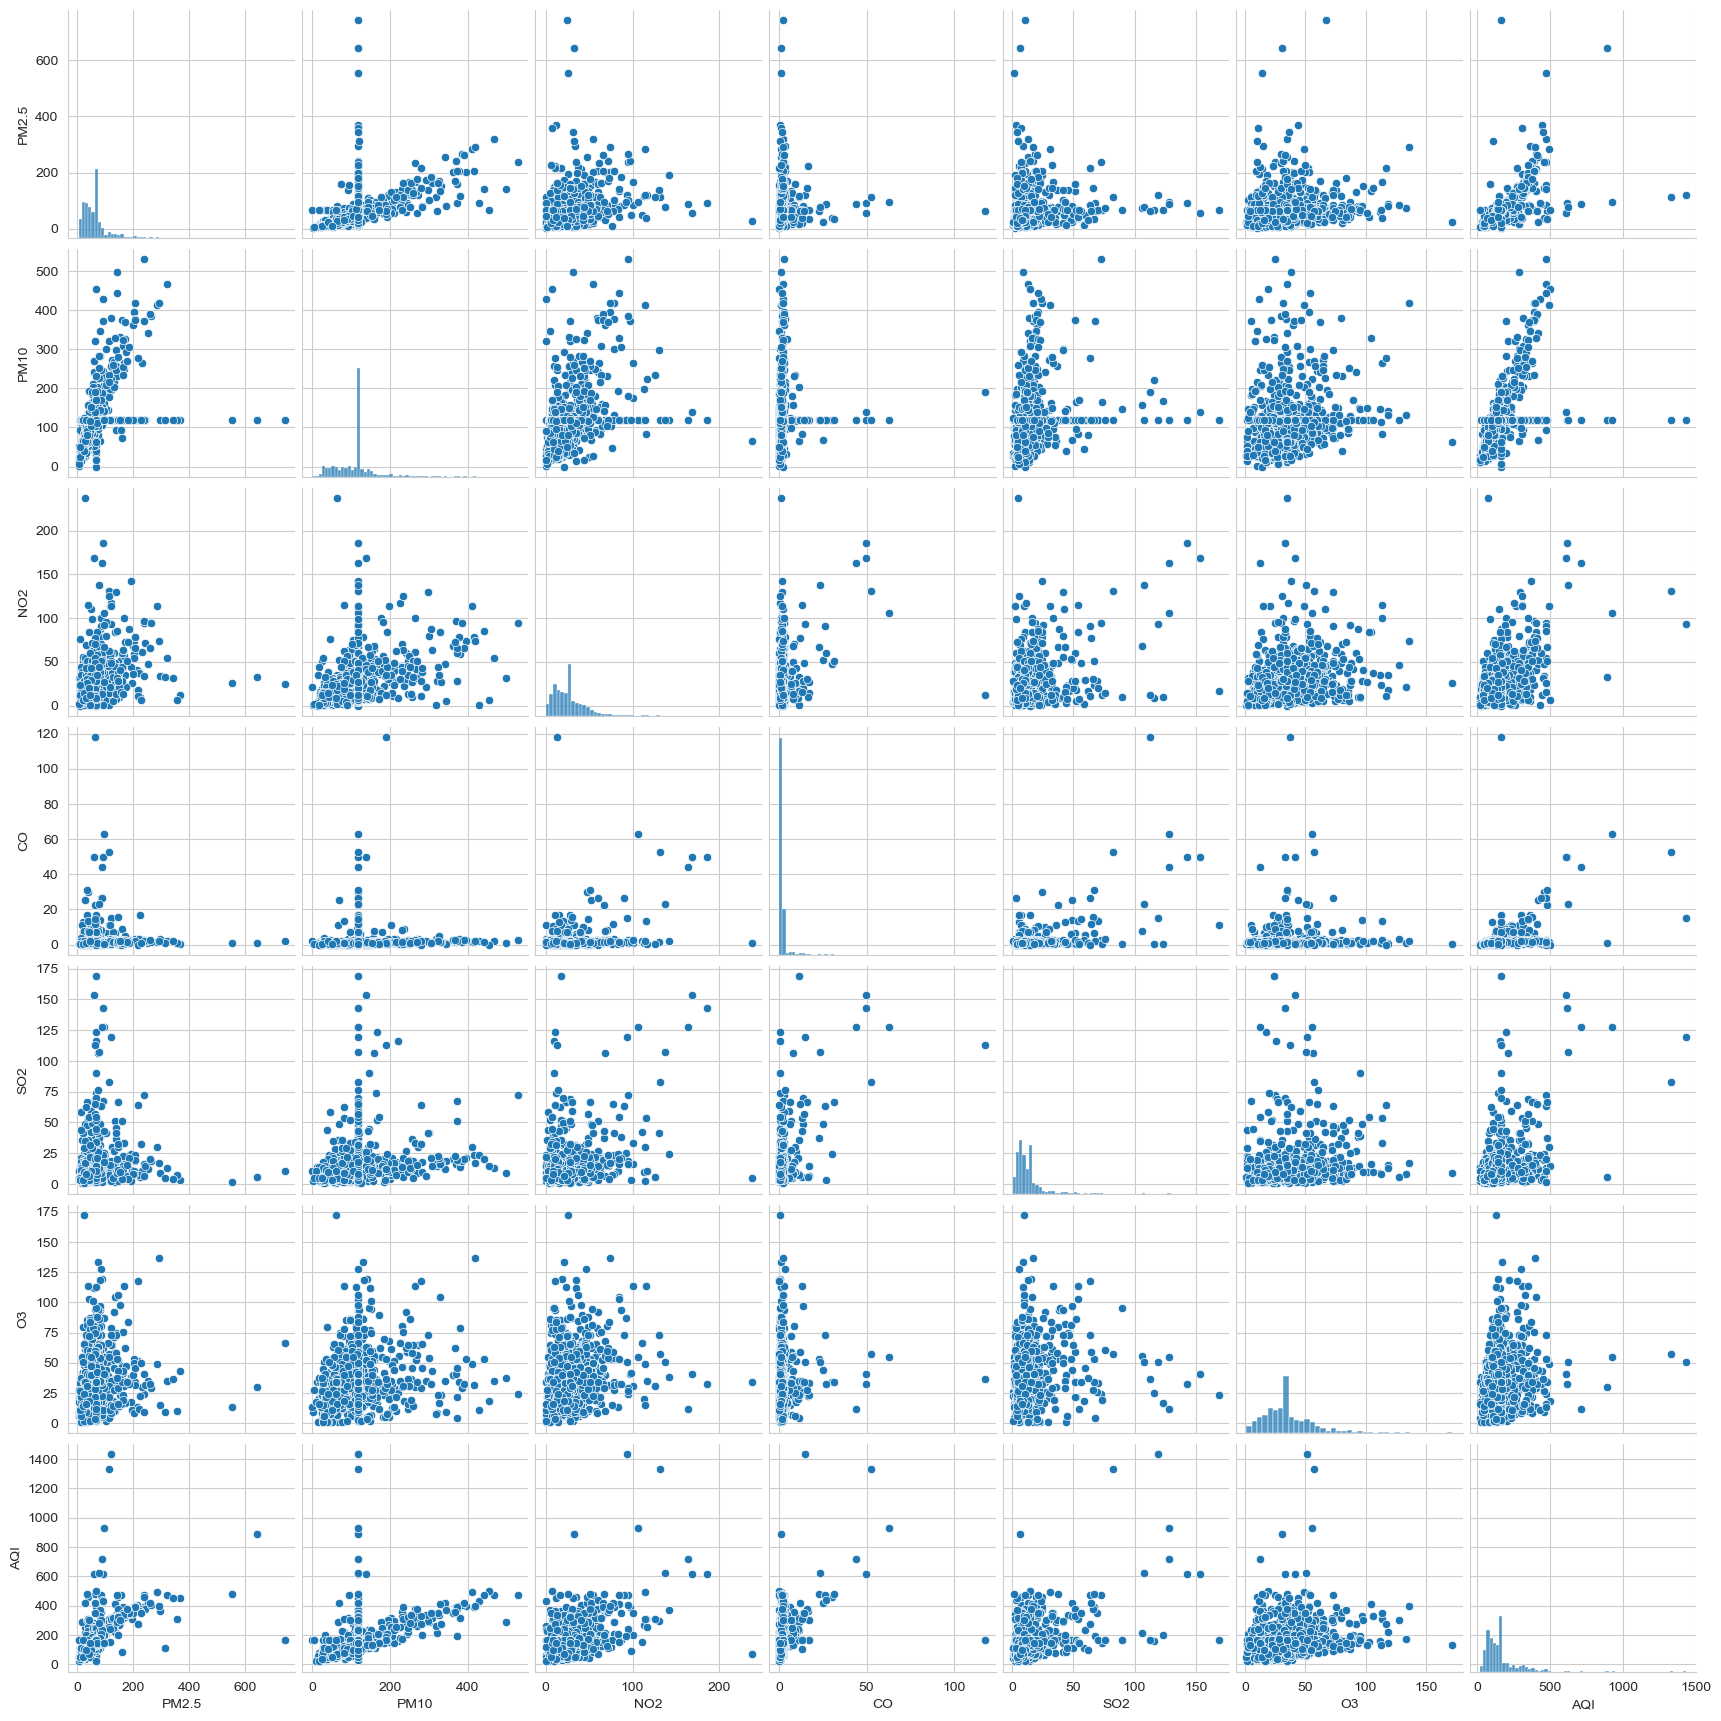

In [101]:
sns.pairplot(data[pollutants + ['AQI']].sample(1000))
plt.show()

In [102]:
data = pd.get_dummies(data, columns=['City'], drop_first=True)

In [103]:
X = data.drop(['AQI','AQI_Bucket'], axis=1)
y = data['AQI']

In [104]:
X = data.drop(['AQI', 'AQI_Bucket'], axis=1)

In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [106]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

lr = LinearRegression()
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)

gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05)
svr = SVR(kernel='rbf')

In [107]:
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gbr.fit(X_train, y_train)
svr.fit(X_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [108]:
def evaluate(name, y_test, pred):
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)

    accuracy = r2 * 100  # Convert to %

    print(f"{name}")
    print(f"Accuracy (R2): {accuracy:.2f}%")
    print(f"R2 Score: {r2:.4f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print("-"*40)

    return accuracy

In [110]:
results = {}
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

gbr_pred = gbr.predict(X_test)
svr_pred = svr.predict(X_test)

results["Linear"] = evaluate("Linear", y_test, lr_pred)
results["Decision Tree"] = evaluate("Decision Tree", y_test, dt_pred)
results["Random Forest"] = evaluate("Random Forest", y_test, rf_pred)
results["Gradient Boosting"] = evaluate("Gradient Boosting", y_test, gbr_pred)
results["SVR"] = evaluate("SVR", y_test, svr_pred)

Linear
Accuracy (R2): 81.39%
R2 Score: 0.8139
RMSE: 52.96
MAE: 30.86
----------------------------------------
Decision Tree
Accuracy (R2): 83.44%
R2 Score: 0.8344
RMSE: 49.97
MAE: 24.38
----------------------------------------
Random Forest
Accuracy (R2): 88.90%
R2 Score: 0.8890
RMSE: 40.91
MAE: 20.31
----------------------------------------
Gradient Boosting
Accuracy (R2): 87.95%
R2 Score: 0.8795
RMSE: 42.62
MAE: 23.36
----------------------------------------
SVR
Accuracy (R2): 28.89%
R2 Score: 0.2889
RMSE: 103.54
MAE: 55.71
----------------------------------------


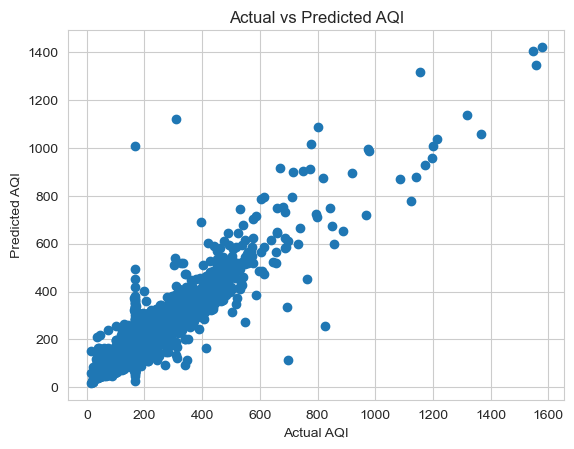

In [111]:
plt.figure()
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.show()

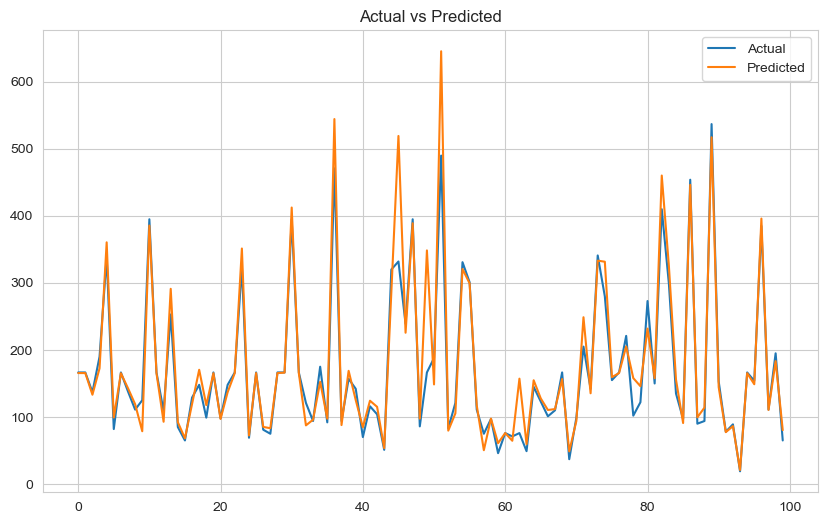

In [112]:
plt.figure(figsize=(10,6))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(rf_pred[:100], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

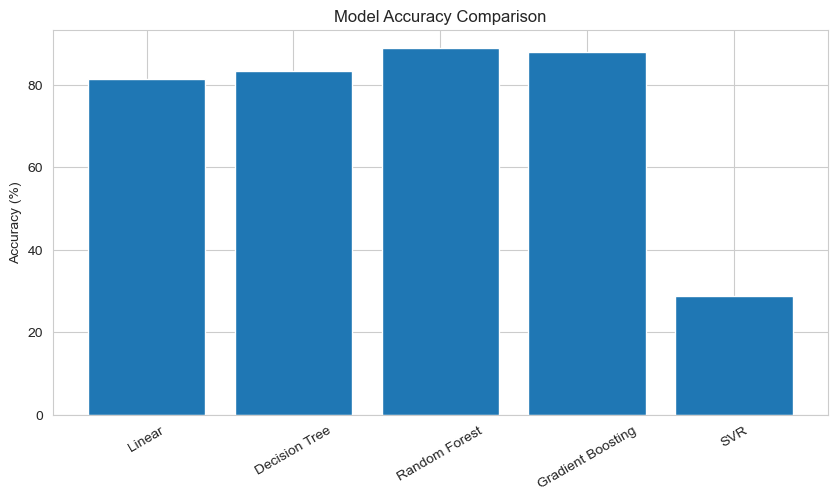

In [113]:
plt.figure(figsize=(10,5))
plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()

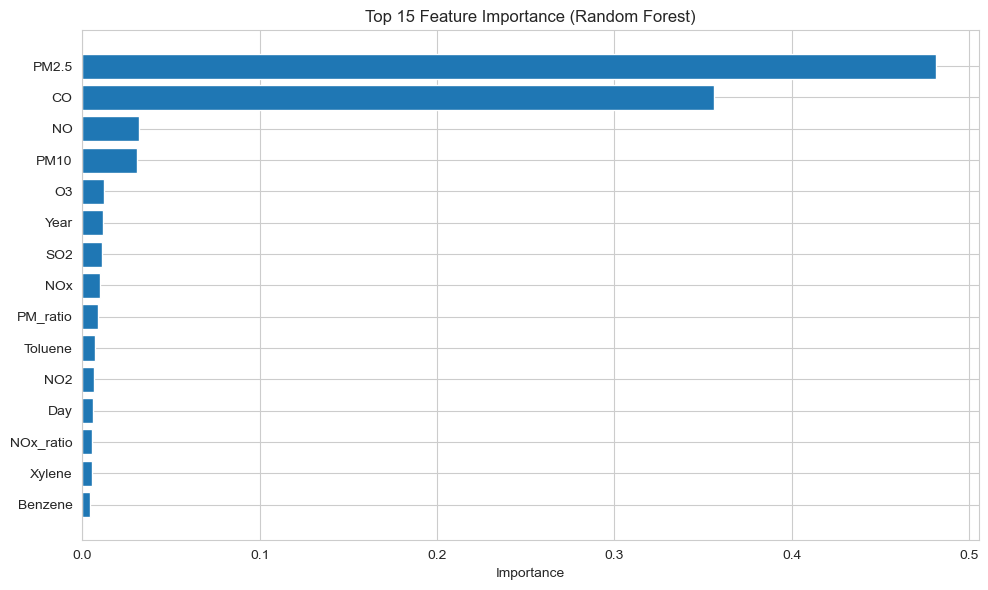

In [117]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = rf.feature_importances_
feature_names = X.columns

# Create DataFrame
feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort values
feat_df = feat_df.sort_values(by="Importance", ascending=False)

# Plot top 15 features
plt.figure(figsize=(10,6))
plt.barh(feat_df["Feature"][:15], feat_df["Importance"][:15])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

In [118]:
from sklearn.model_selection import cross_val_score

cv = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("Cross Validation Accuracy:", round(cv.mean()*100,2), "%")

Cross Validation Accuracy: 74.17 %


In [119]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf, X, y, cv=kf, scoring='r2')

print("K-Fold Scores:", scores)
print("Mean Accuracy:", round(scores.mean()*100, 2), "%")

K-Fold Scores: [0.89165141 0.87896335 0.88120925 0.86254737 0.87950626]
Mean Accuracy: 87.88 %


In [120]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100],
    'max_depth': [10]
}

grid = GridSearchCV(RandomForestRegressor(), params, cv=2)
grid.fit(X_train, y_train)

rf = grid.best_estimator_

In [121]:
models = {
    "Linear": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gbr,
    "SVR": svr
}

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [122]:
# Convert back to DataFrame
new_data = pd.DataFrame(X_train[0:1], columns=data.drop(['AQI','AQI_Bucket'], axis=1).columns)

# Update values
new_data.loc[new_data.index[0], 'PM2.5'] = 50
new_data.loc[new_data.index[0], 'PM10'] = 1400
new_data.loc[new_data.index[0], 'NO2'] = 30
new_data.loc[new_data.index[0], 'NO'] = 20
new_data.loc[new_data.index[0], 'CO'] = 1
new_data.loc[new_data.index[0], 'SO2'] = 10
new_data.loc[new_data.index[0], 'O3'] = 20

# Recreate engineered features
new_data['PM_ratio'] = new_data['PM2.5'] / (new_data['PM10'] + 1)
new_data['NOx_ratio'] = new_data['NO'] / (new_data['NO2'] + 1)

# Scale again
new_data_scaled = scaler.transform(new_data)

# Predict
prediction = best_model.predict(new_data)
print("Predicted AQI:", prediction[0])

Predicted AQI: 331.35554476456366


In [123]:
import joblib

# Save your trained model
joblib.dump(rf, "aqi_model.pkl")   # if using Random Forest


['aqi_model.pkl']

In [124]:
import joblib
joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']